# Proyek Machine Learning: Coffee Sales Forecasting dan Customer Purchase Pattern Analysis

---
**Nama:** Walker Valentinus Simanjuntak  
**Email:** walkervalentinussimanjuntak@gmail.com  
**ID Dicoding:** walkervs

---

## Project Overview

Proyek ini bertujuan untuk menganalisis pola penjualan kopi dari sebuah *vending machine* dan membangun model peramalan (*forecasting*) penjualan harian. Dataset yang digunakan adalah **Coffee Sales** dari Kaggle (Isaienkov, 2025), yang berisi catatan transaksi individual meliputi tanggal, waktu, metode pembayaran, identitas pelanggan (anonymized), nilai transaksi, dan nama produk kopi yang dibeli.

Proyek ini mencakup tiga tugas utama:
1. **Time Series Exploratory Data Analysis (EDA)** — memahami tren, pola waktu, dan distribusi penjualan.
2. **Customer Purchase Analysis** — menganalisis pola pembelian pelanggan berdasarkan identifier `card`.
3. **Sales Forecasting** — memprediksi total penjualan harian berikutnya menggunakan lima pendekatan berbeda.

## Business Understanding

### Problem Statements
1. Bagaimana tren dan pola penjualan kopi dari *vending machine* berdasarkan waktu?
2. Siapa pelanggan paling aktif dan produk apa yang paling sering dibeli?
3. Model mana yang memberikan error terkecil dalam memprediksi total penjualan kopi harian berikutnya?

### Goals
1. Memahami tren penjualan historis dan pola temporal dari data transaksi *vending machine*.
2. Mengidentifikasi pelanggan dengan frekuensi transaksi dan total pengeluaran tertinggi.
3. Membangun dan membandingkan lima model peramalan untuk menentukan model terbaik secara empiris.

### Solution Statements
Dua solusi yang dapat diukur (*measurable*) diusulkan:
- **Solusi 1:** Membandingkan tiga model *baseline Machine Learning* (KNN, Random Forest, AdaBoost) dengan dua pendekatan tambahan (Simple Linear Regression, Fuzzy Time Series). Evaluasi menggunakan **MSE** untuk baseline, **MAPE** untuk pendekatan tambahan, dan **RMSE** serta **MAE** sebagai metrik pembanding universal untuk seluruh model.
- **Solusi 2:** Melakukan *hyperparameter tuning* pada model baseline terbaik menggunakan `GridSearchCV` dengan `TimeSeriesSplit` untuk meningkatkan performa peramalan, yang dapat diukur dengan penurunan nilai RMSE dibandingkan model *default*.


## 1. Import Library

Mengimpor seluruh library yang diperlukan untuk analisis data, visualisasi, dan pemodelan *Machine Learning*.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print("Library berhasil diimpor.")


Library berhasil diimpor.


## 2. Data Loading dan Data Understanding

### Sumber Data
Dataset: **Coffee Sales** (Isaienkov, Y., 2025). Kaggle. https://doi.org/10.34740/KAGGLE/DSV/11159944

Dataset ini berisi catatan transaksi penjualan kopi dari sebuah *vending machine*. Setiap baris mewakili satu transaksi individual.

### Deskripsi Fitur
| Kolom | Tipe | Deskripsi |
|---|---|---|
| `date` | Date | Tanggal transaksi |
| `datetime` | Datetime | Tanggal dan waktu transaksi |
| `cash_type` | Categorical | Metode pembayaran (`card` / `cash`) |
| `card` | Identifier | Identitas pelanggan yang dianonimkan (tersedia jika bayar kartu) |
| `money` | Numerical | Nilai transaksi (mata uang lokal) |
| `coffee_name` | Categorical | Nama produk kopi yang dibeli |


In [2]:
# Memuat dataset
df_raw = pd.read_csv('CoffeeSales/index_1.csv', parse_dates=['date', 'datetime'])

print("=== Info Dataset ===")
print(df_raw.info())
print()
print("=== 5 Baris Pertama ===")
display(df_raw.head())
print()
print(f"Jumlah baris: {len(df_raw):,}")
print(f"Jumlah kolom: {df_raw.shape[1]}")
print(f"Rentang tanggal: {df_raw['date'].min().date()} s.d. {df_raw['date'].max().date()}")


=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[us]
 1   datetime     3636 non-null   datetime64[us]
 2   cash_type    3636 non-null   str           
 3   card         3547 non-null   str           
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   str           
dtypes: datetime64[us](2), float64(1), str(3)
memory usage: 170.6 KB
None

=== 5 Baris Pertama ===


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte



Jumlah baris: 3,636
Jumlah kolom: 6
Rentang tanggal: 2024-03-01 s.d. 2025-03-23


## 3. Data Quality Check

Memeriksa keberadaan *missing values* dan data duplikat sebelum analisis lebih lanjut.

**Catatan tentang kolom `card`:** Nilai kosong pada `card` bukan merupakan kesalahan data — hal ini terjadi karena transaksi tunai (`cash`) tidak memiliki identitas kartu pelanggan. Missing values ini akan dibiarkan dan hanya digunakan pada analisis pelanggan berbasis kartu.


In [3]:
print("=== Missing Values ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct}))

print()
print(f"=== Duplikat ===")
n_dup = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dup}")

# Hapus duplikat jika ada
if n_dup > 0:
    df_raw = df_raw.drop_duplicates()
    print(f"Duplikat dihapus. Sisa data: {len(df_raw):,} baris")
else:
    print("Tidak ada duplikat.")

print()
print("=== Statistik Deskriptif (money) ===")
display(df_raw[['money']].describe())


=== Missing Values ===
             Jumlah Missing  Persentase (%)
date                      0            0.00
datetime                  0            0.00
cash_type                 0            0.00
card                     89            2.45
money                     0            0.00
coffee_name               0            0.00

=== Duplikat ===
Jumlah baris duplikat: 0
Tidak ada duplikat.

=== Statistik Deskriptif (money) ===


,money
count,3636.000000
mean,31.746859
std,4.919926
min,18.120000
25%,27.920000
50%,32.820000
75%,35.760000
max,40.000000


### Deteksi Outlier

Outlier dideteksi menggunakan metode **Interquartile Range (IQR)** pada variabel `money`. Outlier adalah nilai yang berada di luar rentang normal (di bawah Q1 - 1.5*IQR atau di atas Q3 + 1.5*IQR).


=== Deteksi Outlier (money) ===
Q1: 27.92, Q3: 35.76, IQR: 7.84
Batas bawah: 16.16
Batas atas : 47.52
Jumlah outlier: 0 (0.00%)


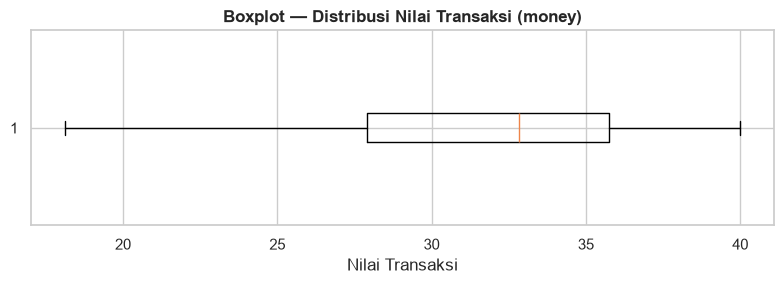

In [4]:
# Deteksi Outlier pada variabel 'money' menggunakan metode IQR
Q1 = df_raw['money'].quantile(0.25)
Q3 = df_raw['money'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_raw[(df_raw['money'] < lower_bound) | (df_raw['money'] > upper_bound)]
print(f"=== Deteksi Outlier (money) ===")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Batas bawah: {lower_bound:.2f}")
print(f"Batas atas : {upper_bound:.2f}")
print(f"Jumlah outlier: {len(outliers)} ({len(outliers)/len(df_raw)*100:.2f}%)")

# Visualisasi boxplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(df_raw['money'], vert=False)
ax.set_title('Boxplot — Distribusi Nilai Transaksi (money)', fontweight='bold')
ax.set_xlabel('Nilai Transaksi')
plt.tight_layout()
plt.show()


## 4. Exploratory Data Analysis (EDA)

### 4.1 Tren Penjualan Harian

Visualisasi total pendapatan harian untuk memahami tren keseluruhan dan mengidentifikasi anomali.


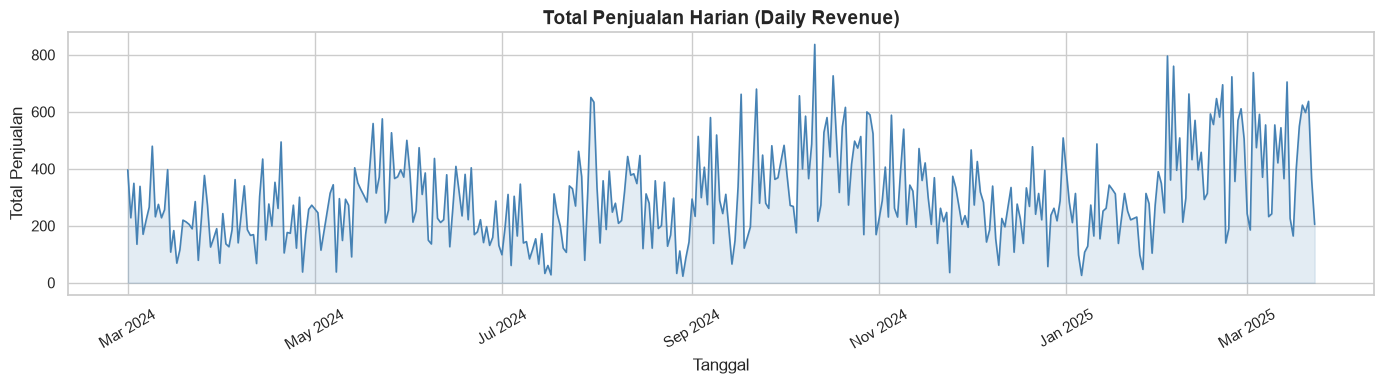

In [5]:
daily_sales = df_raw.groupby('date')['money'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_sales['date'], daily_sales['total_sales'], color='steelblue', linewidth=1.2)
ax.fill_between(daily_sales['date'], daily_sales['total_sales'], alpha=0.15, color='steelblue')
ax.set_title('Total Penjualan Harian (Daily Revenue)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Total Penjualan')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 4.2 Pola Temporal (Jam, Hari, Bulan)

Menganalisis kapan transaksi paling banyak terjadi berdasarkan jam dalam sehari, hari dalam seminggu, dan bulan dalam setahun.


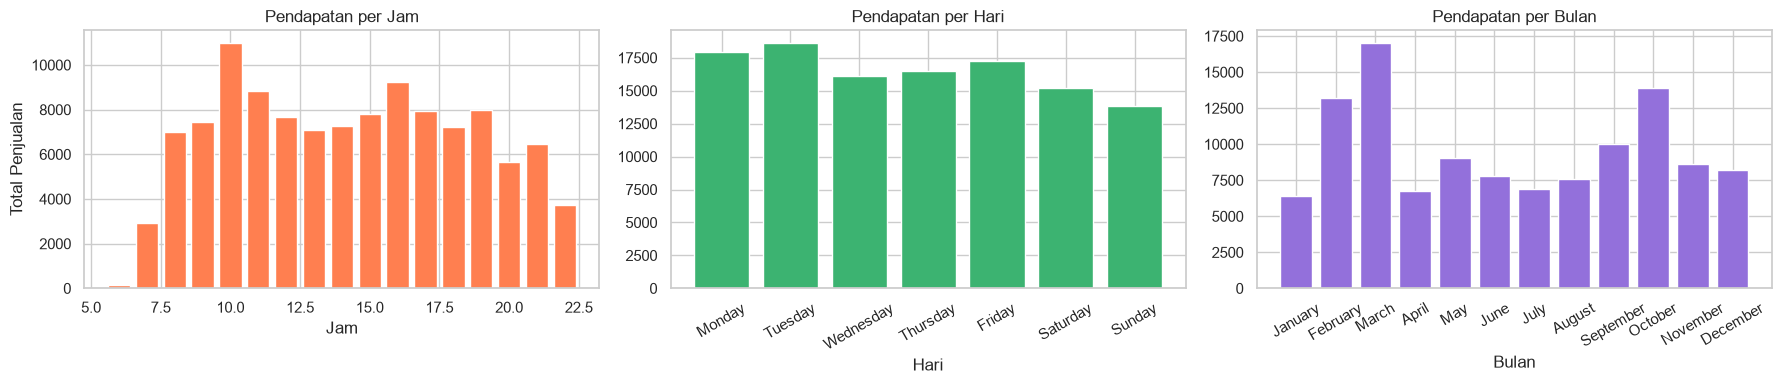

In [6]:
df_raw['hour'] = df_raw['datetime'].dt.hour
df_raw['day_of_week'] = df_raw['datetime'].dt.day_name()
df_raw['month'] = df_raw['datetime'].dt.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# By Hour
hourly = df_raw.groupby('hour')['money'].sum()
axes[0].bar(hourly.index, hourly.values, color='coral')
axes[0].set_title('Pendapatan per Jam')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Total Penjualan')

# By Day of Week
dow = df_raw.groupby('day_of_week')['money'].sum().reindex(day_order)
axes[1].bar(dow.index, dow.values, color='mediumseagreen')
axes[1].set_title('Pendapatan per Hari')
axes[1].set_xlabel('Hari')
axes[1].tick_params(axis='x', rotation=30)

# By Month
monthly = df_raw.groupby('month')['money'].sum().reindex(month_order).dropna()
axes[2].bar(monthly.index, monthly.values, color='mediumpurple')
axes[2].set_title('Pendapatan per Bulan')
axes[2].set_xlabel('Bulan')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 4.3 Distribusi Produk Kopi

Menganalisis produk kopi yang paling populer berdasarkan jumlah transaksi dan total pendapatan.


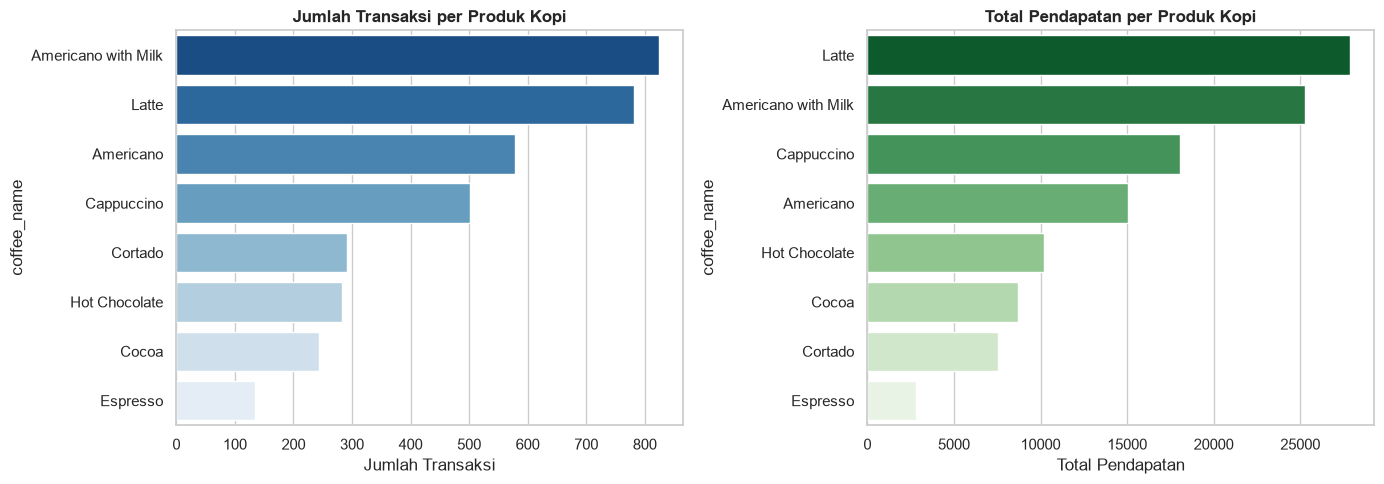

In [7]:
product_txn = df_raw['coffee_name'].value_counts()
product_rev = df_raw.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(y=product_txn.index, x=product_txn.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Jumlah Transaksi per Produk Kopi', fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi')

sns.barplot(y=product_rev.index, x=product_rev.values, ax=axes[1], palette='Greens_r')
axes[1].set_title('Total Pendapatan per Produk Kopi', fontweight='bold')
axes[1].set_xlabel('Total Pendapatan')

plt.tight_layout()
plt.show()


### 4.4 Distribusi Metode Pembayaran


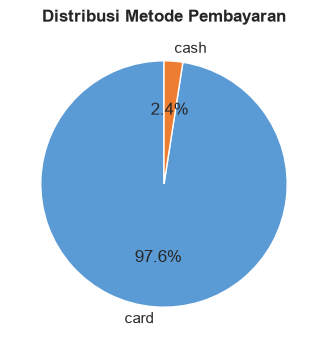

In [8]:
payment = df_raw['cash_type'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(payment.values, labels=payment.index, autopct='%1.1f%%', startangle=90,
       colors=['#5B9BD5', '#ED7D31'])
ax.set_title('Distribusi Metode Pembayaran', fontweight='bold')
plt.show()


## 5. Customer Purchase Analysis

Menganalisis pola pembelian pelanggan berdasarkan kolom `card` (identifier yang dianonimkan). Hanya transaksi yang menggunakan kartu yang memiliki identifier pelanggan.


=== Top 10 Pelanggan (berdasarkan jumlah transaksi) ===


,total_transactions,total_spending,avg_transaction,favourite_product
card,,,,
ANON-0000-0000-0012,129,3785.92,29.348217,Americano
ANON-0000-0000-0141,108,2749.78,25.460926,Cortado
ANON-0000-0000-1163,77,2278.22,29.587273,Americano
ANON-0000-0000-0276,69,2119.54,30.717971,Americano with Milk
ANON-0000-0000-0009,67,2343.98,34.984776,Latte
ANON-0000-0000-0507,51,1797.30,35.241176,Latte
ANON-0000-0000-0040,50,1519.48,30.389600,Americano with Milk
ANON-0000-0000-0097,47,1477.86,31.443830,Americano with Milk
ANON-0000-0000-1110,33,886.08,26.850909,Americano


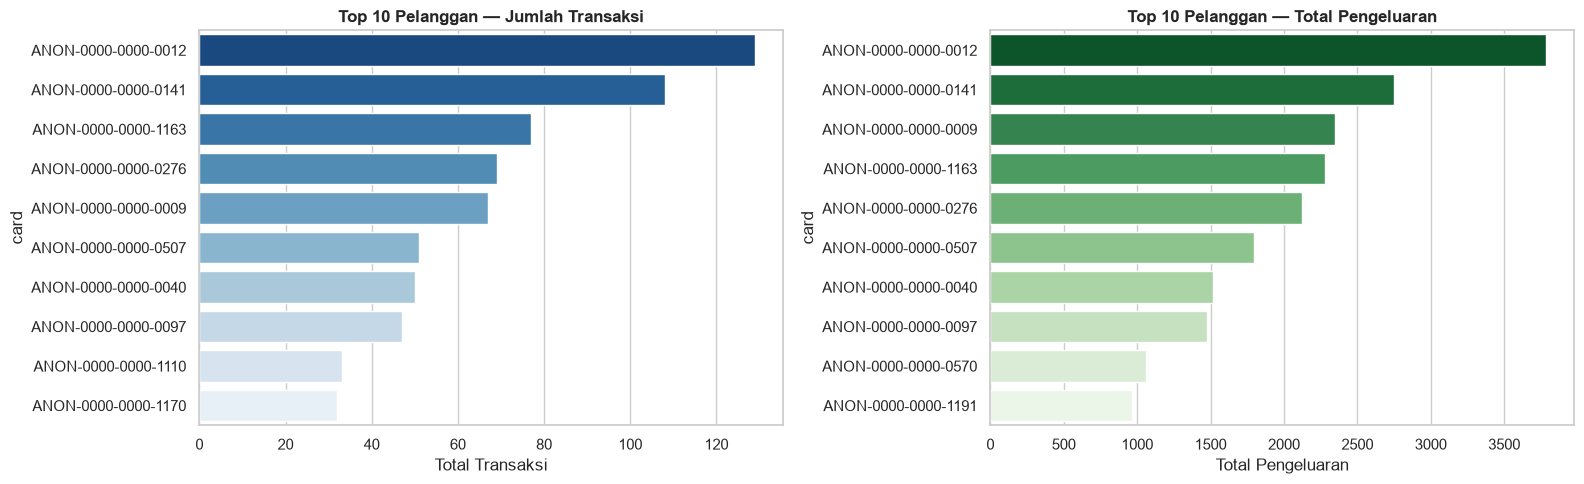

In [9]:
df_card = df_raw[df_raw['card'].notnull()].copy()

# Agregasi per pelanggan
customer_stats = df_card.groupby('card').agg(
    total_transactions=('money', 'count'),
    total_spending=('money', 'sum'),
    avg_transaction=('money', 'mean'),
    favourite_product=('coffee_name', lambda x: x.mode()[0])
).sort_values('total_transactions', ascending=False)

print("=== Top 10 Pelanggan (berdasarkan jumlah transaksi) ===")
display(customer_stats.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 by transactions
top_10_txn = customer_stats.head(10)
sns.barplot(y=top_10_txn.index, x=top_10_txn['total_transactions'], ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Pelanggan — Jumlah Transaksi', fontweight='bold')
axes[0].set_xlabel('Total Transaksi')

# Top 10 by spending
top_10_spend = customer_stats.sort_values('total_spending', ascending=False).head(10)
sns.barplot(y=top_10_spend.index, x=top_10_spend['total_spending'], ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Pelanggan — Total Pengeluaran', fontweight='bold')
axes[1].set_xlabel('Total Pengeluaran')

plt.tight_layout()
plt.show()


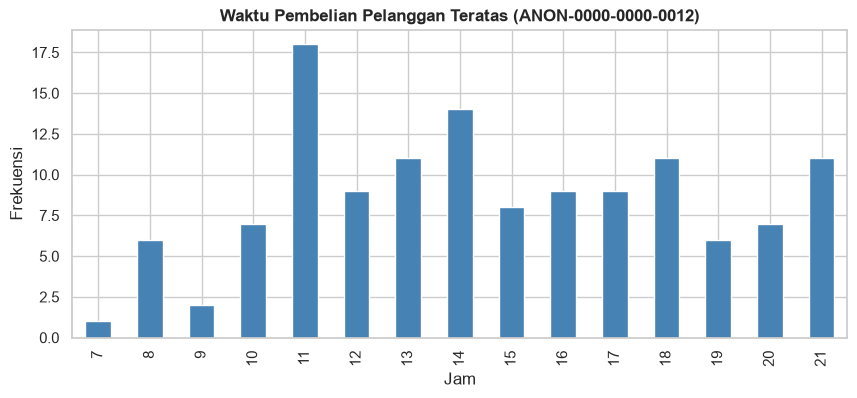

Produk favorit: Americano
Total transaksi: 129
Total pengeluaran: 3785.9


In [10]:
# Waktu pembelian top-1 pelanggan
top_customer = customer_stats.index[0]
df_top = df_card[df_card['card'] == top_customer]

plt.figure(figsize=(10, 4))
df_top['hour'] = df_top['datetime'].dt.hour
df_top['hour'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title(f'Waktu Pembelian Pelanggan Teratas ({top_customer})', fontweight='bold')
plt.xlabel('Jam')
plt.ylabel('Frekuensi')
plt.show()
print(f"Produk favorit: {df_top['coffee_name'].mode()[0]}")
print(f"Total transaksi: {len(df_top)}")
print(f"Total pengeluaran: {df_top['money'].sum():.1f}")


## 6. Data Preparation

### 6.1 Agregasi Waktu (Time Aggregation)
Data transaksi individual diubah menjadi **total penjualan harian** dengan menjumlahkan kolom `money` per hari.

**Alasan:** Model peramalan tidak bisa memprediksi per transaksi karena tidak ada fitur yang membedakan satu transaksi dari transaksi lain pada hari yang sama. Agregasi harian menghasilkan *target variable* yang representatif dan memungkinkan pemodelan berbasis pola waktu.

**Catatan:** Hari tanpa transaksi (libur/tutup) diisi dengan `0` agar deret waktu lengkap dan kontinu.


In [11]:
# Agregasi harian
df_ts = df_raw.groupby('date')['money'].sum().reset_index()
df_ts.set_index('date', inplace=True)
df_ts = df_ts.asfreq('D').fillna(0)
df_ts.rename(columns={'money': 'target_sales'}, inplace=True)

print(f"Jumlah hari dalam dataset: {len(df_ts)}")
print(f"Hari dengan penjualan > 0: {(df_ts['target_sales'] > 0).sum()}")
print(f"Hari dengan penjualan = 0 (tutup/libur): {(df_ts['target_sales'] == 0).sum()}")
display(df_ts.head())


Jumlah hari dalam dataset: 388
Hari dengan penjualan > 0: 381
Hari dengan penjualan = 0 (tutup/libur): 7


,target_sales
date,
2024-03-01,396.3
2024-03-02,228.1
2024-03-03,349.1
2024-03-04,135.2
2024-03-05,338.5


### 6.2 Feature Engineering

Membuat fitur-fitur yang merepresentasikan informasi historis dan kalender:

| Fitur | Deskripsi | Alasan |
|---|---|---|
| `lag_1` | Penjualan hari sebelumnya | Nilai terkini paling relevan untuk prediksi besok |
| `lag_7` | Penjualan 7 hari lalu (hari yang sama minggu lalu) | Menangkap pola mingguan berulang |
| `day_of_week` | Hari dalam seminggu (0=Senin, 6=Minggu) | Pola penjualan berbeda antar hari |
| `is_weekend` | 1 jika Sabtu/Minggu, 0 jika tidak | Perbedaan perilaku pelanggan di akhir pekan |
| `month` | Bulan (1–12) | Menangkap pola musiman |

**Leakage Prevention:** Semua lag hanya menggunakan nilai historis (sebelum waktu `t`), tidak ada informasi masa depan.


In [12]:
df_ts['lag_1'] = df_ts['target_sales'].shift(1)
df_ts['lag_7'] = df_ts['target_sales'].shift(7)
df_ts['day_of_week'] = df_ts.index.dayofweek
df_ts['is_weekend'] = (df_ts['day_of_week'] >= 5).astype(int)
df_ts['month'] = df_ts.index.month

# Hapus baris awal yang memiliki NaN akibat shifting
df_ts.dropna(inplace=True)

print(f"Jumlah hari setelah lag (data siap pakai): {len(df_ts)}")
display(df_ts.head())


Jumlah hari setelah lag (data siap pakai): 381


,target_sales,lag_1,lag_7,day_of_week,is_weekend,month
date,,,,,,
2024-03-08,265.5,220.1,396.3,4,0,3
2024-03-09,479.4,265.5,228.1,5,1,3
2024-03-10,231.6,479.4,349.1,6,1,3
2024-03-11,275.2,231.6,135.2,0,0,3
2024-03-12,228.1,275.2,338.5,1,0,3


### 6.3 Train/Test Split (Kronologis)

Data dibagi secara **kronologis** — 80% pertama untuk pelatihan, 20% terakhir untuk pengujian.

**Mengapa kronologis, bukan acak?**
Pada peramalan deret waktu, mengacak data menyebabkan *temporal data leakage*: model bisa "melihat" data dari masa depan saat pelatihan. Ini menghasilkan evaluasi yang terlalu optimis dan tidak valid secara metodologis. Pembagian kronologis memastikan model hanya dilatih dengan data yang benar-benar "tersedia sebelum periode uji".


In [13]:
features = ['lag_1', 'lag_7', 'day_of_week', 'is_weekend', 'month']
target = 'target_sales'

train_size = int(len(df_ts) * 0.8)
train = df_ts.iloc[:train_size]
test  = df_ts.iloc[train_size:]

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

print(f"Periode Latih : {train.index.min().date()} s.d. {train.index.max().date()} ({len(train)} hari)")
print(f"Periode Uji  : {test.index.min().date()} s.d. {test.index.max().date()} ({len(test)} hari)")


Periode Latih : 2024-03-08 s.d. 2025-01-05 (304 hari)
Periode Uji  : 2025-01-06 s.d. 2025-03-23 (77 hari)


### 6.4 Standarisasi Fitur

`StandardScaler` digunakan untuk menormalkan fitur ke skala rata-rata 0 dan standar deviasi 1.

**Alasan:** KNN sangat sensitif terhadap perbedaan skala antar fitur (misalnya `lag_1` vs `month`). Standarisasi memastikan semua fitur berkontribusi secara proporsional. Penting: scaler **di-fit hanya pada data latih** dan kemudian di-*transform* ke data latih dan data uji — ini mencegah kebocoran informasi statistik dari data uji ke data latih.


In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform pada data latih
X_test_sc  = scaler.transform(X_test)        # hanya transform pada data uji

print("Standarisasi selesai. Scaler di-fit hanya pada data latih.")


Standarisasi selesai. Scaler di-fit hanya pada data latih.


## 7. Modeling: Baseline (KNN, Random Forest, AdaBoost)

Tiga model *Machine Learning* digunakan sebagai baseline. Evaluasi utama menggunakan **MSE**, serta **RMSE** dan **MAE** sebagai metrik pembanding universal.

### Fungsi Evaluasi


In [15]:
results = {}

def evaluate_model(name, y_true, y_pred, primary_metric='mse'):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    
    # MAPE — hanya dihitung pada hari dengan penjualan > 0 untuk menghindari divisi nol
    mask = np.array(y_true) > 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((np.array(y_true)[mask] - np.array(y_pred)[mask]) / np.array(y_true)[mask])) * 100
    else:
        mape = np.nan
    
    results[name] = {
        'MSE'  : round(mse, 2)  if primary_metric == 'mse'  else '-',
        'MAPE (%)': round(mape, 2) if primary_metric == 'mape' else '-',
        'RMSE' : round(rmse, 2),
        'MAE'  : round(mae, 2)
    }
    
    print(f"--- {name} ---")
    if primary_metric == 'mse':
        print(f"  MSE    : {mse:,.4f}")
    else:
        print(f"  MAPE   : {mape:.2f}%")
    print(f"  RMSE   : {rmse:,.4f}")
    print(f"  MAE    : {mae:,.4f}")
    print()

print("Fungsi evaluasi siap digunakan.")


Fungsi evaluasi siap digunakan.


### 7.1 K-Nearest Neighbors (KNN)

**Kelebihan:** Sederhana, tidak memerlukan asumsi distribusi data, mudah diinterpretasikan.  
**Kekurangan:** Tidak dapat mengekstrapolasi tren di luar rentang data latih; performa menurun pada dimensi fitur yang tinggi (*curse of dimensionality*).


In [16]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_sc, y_train)
knn_preds = knn.predict(X_test_sc)
evaluate_model('KNN (default)', y_true=y_test, y_pred=knn_preds, primary_metric='mse')


--- KNN (default) ---
  MSE    : 54,191.7380
  RMSE   : 232.7912
  MAE    : 182.2870



### 7.2 Random Forest

**Kelebihan:** Robust terhadap *overfitting*, mampu menangkap hubungan non-linear antara fitur dan target, menghasilkan *feature importance*.  
**Kekurangan:** Tidak dapat mengekstrapolasi tren di luar rentang data latih, perlu lebih banyak komputasi dibandingkan model tunggal.


In [17]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
rf_preds = rf.predict(X_test_sc)
evaluate_model('Random Forest (default)', y_true=y_test, y_pred=rf_preds, primary_metric='mse')


--- Random Forest (default) ---
  MSE    : 74,766.1245
  RMSE   : 273.4339
  MAE    : 214.5087



### 7.3 AdaBoost

**Kelebihan:** Menggunakan teknik *boosting* (belajar secara berurutan dari kesalahan model sebelumnya), sehingga dapat mengurangi *bias*.  
**Kekurangan:** Rentan terhadap *outlier* karena memberikan bobot lebih besar pada data yang salah diklasifikasikan; dapat *overfit* jika terlalu banyak estimator.


In [18]:
ada = AdaBoostRegressor(n_estimators=50, random_state=42)
ada.fit(X_train_sc, y_train)
ada_preds = ada.predict(X_test_sc)
evaluate_model('AdaBoost (default)', y_true=y_test, y_pred=ada_preds, primary_metric='mse')


--- AdaBoost (default) ---
  MSE    : 50,465.3209
  RMSE   : 224.6449
  MAE    : 170.2222



## 8. Modeling: Pendekatan Tambahan

### 8.1 Simple Linear Regression (SLR)

SLR adalah model statistik paling dasar yang mengasumsikan hubungan **linear** antara satu variabel independen dan variabel target. Berdasarkan literatur (*Sales Prediction using Linear Regression*, ResearchGate), pendekatan regresi linear terbukti berguna untuk prediksi penjualan.

Sebagai *Simple* LR, hanya satu variabel independen yang digunakan: `lag_1` (penjualan hari sebelumnya), karena secara intuitif penjualan hari ini sangat bergantung pada penjualan kemarin.

**Kelebihan:** Sederhana, mudah diinterpretasikan melalui koefisien.  
**Kekurangan:** Mengasumsikan linearitas; tidak mampu menangkap pola non-linear atau interaksi antar fitur.

Evaluasi tambahan menggunakan **MAPE** (dihitung hanya pada hari dengan penjualan > 0 untuk menghindari pembagian dengan nol).


In [19]:
X_train_slr = train[['lag_1']]
X_test_slr  = test[['lag_1']]

slr = LinearRegression()
slr.fit(X_train_slr, y_train)
slr_preds = slr.predict(X_test_slr)

evaluate_model('Simple Linear Regression', y_true=y_test, y_pred=slr_preds, primary_metric='mape')

print(f"Koefisien SLR (slope)   : {slr.coef_[0]:.4f}")
print(f"Intercept               : {slr.intercept_:.4f}")
print("Interpretasi: Setiap kenaikan 1 unit penjualan kemarin, prediksi penjualan besok naik sebesar {:.4f} unit.".format(slr.coef_[0]))


--- Simple Linear Regression ---
  MAPE   : 56.31%
  RMSE   : 200.2434
  MAE    : 155.4222

Koefisien SLR (slope)   : 0.2646
Intercept               : 205.2682
Interpretasi: Setiap kenaikan 1 unit penjualan kemarin, prediksi penjualan besok naik sebesar 0.2646 unit.


### 8.2 Fuzzy Time Series (FTS) — Implementasi Manual (Algoritma Chen 1996)

**Apa itu Fuzzy Time Series?**
Fuzzy Time Series (FTS) adalah metode peramalan yang mengubah data numerik menjadi himpunan fuzzy berdasarkan interval yang ditentukan. Metode ini dikembangkan oleh Song & Chissom (1993) dan disederhanakan oleh Chen (1996). FTS sangat berguna untuk data dengan ketidakpastian dan tidak memerlukan asumsi distribusi tertentu.

**Cara kerja (Algoritma Chen):**
1. Tentukan *universe of discourse* [D_min, D_max].
2. Bagi interval menjadi beberapa bagian yang sama (*partisi*).
3. Fuzzifikasi: setiap nilai historis dipetakan ke label fuzzy (A1, A2, ..., An).
4. Buat *Fuzzy Logical Relationships* (FLR) dan kelompokkan (*FLRG*).
5. Defuzzifikasi: rata-rata tengah interval dari relasi yang cocok digunakan sebagai prediksi.

Referensi: Penelitian terkait Fuzzy Time Series dan Simple Linear Regression. *International Journal of Data and Operational Systems, 6(3)*. https://doi.org/10.56705/ijodas.v6i3.368


In [20]:
def chen_fts_forecast(train_series, test_series, n_intervals=10):
    """
    Implementasi manual Fuzzy Time Series berdasarkan Algoritma Chen (1996).
    
    Parameter:
    - train_series: array penjualan harian (data latih)
    - test_series : array penjualan harian (data uji, digunakan untuk menggerakkan prediksi satu langkah)
    - n_intervals : jumlah partisi interval fuzzy
    
    Return:
    - predictions: array prediksi untuk data uji
    """
    all_data = np.concatenate([train_series, test_series])
    
    # 1. Universe of discourse
    d_min = min(all_data) * 0.9
    d_max = max(all_data) * 1.1
    interval_len = (d_max - d_min) / n_intervals
    
    # 2. Buat batas interval dan midpoint
    boundaries = [d_min + i * interval_len for i in range(n_intervals + 1)]
    midpoints  = [(boundaries[i] + boundaries[i+1]) / 2 for i in range(n_intervals)]
    
    # 3. Fungsi fuzzifikasi — kembalikan indeks interval yang sesuai
    def fuzzify(value):
        for i in range(n_intervals):
            if boundaries[i] <= value < boundaries[i+1]:
                return i
        return n_intervals - 1  # untuk nilai tepat di batas atas
    
    # 4. Fuzzifikasi data latih
    fuzzified_train = [fuzzify(v) for v in train_series]
    
    # 5. Buat Fuzzy Logical Relationships (FLR): A_t -> A_{t+1}
    flrg = {}
    for t in range(len(fuzzified_train) - 1):
        current = fuzzified_train[t]
        nxt     = fuzzified_train[t + 1]
        if current not in flrg:
            flrg[current] = []
        flrg[current].append(nxt)
    
    # 6. Defuzzifikasi — rata-rata midpoint dari state tujuan
    def defuzzify(state):
        if state in flrg:
            next_states = flrg[state]
            return np.mean([midpoints[s] for s in next_states])
        else:
            return midpoints[state]  # jika tidak ada relasi, kembalikan midpoint state itu sendiri
    
    # 7. Prediksi untuk data uji (one-step-ahead, menggunakan nilai aktual sebelumnya)
    predictions = []
    prev_value = train_series[-1]   # nilai terakhir data latih sebagai titik awal
    
    for actual in test_series:
        state = fuzzify(prev_value)
        pred  = defuzzify(state)
        predictions.append(pred)
        prev_value = actual  # gunakan nilai aktual untuk langkah berikutnya (one-step-ahead)
    
    return np.array(predictions)

# Jalankan FTS
train_series = train[target].values
test_series  = test[target].values

fts_preds = chen_fts_forecast(train_series, test_series, n_intervals=10)
evaluate_model('Fuzzy Time Series (Chen)', y_true=y_test, y_pred=fts_preds, primary_metric='mape')
print(f"Jumlah prediksi FTS: {len(fts_preds)}")


--- Fuzzy Time Series (Chen) ---
  MAPE   : 60.60%
  RMSE   : 215.7400
  MAE    : 171.9163

Jumlah prediksi FTS: 77


## 9. Hyperparameter Tuning (Solusi 2)

Melakukan *hyperparameter tuning* pada model terbaik dari baseline menggunakan `GridSearchCV` dengan `TimeSeriesSplit` sebagai strategi validasi silang.

**Mengapa `TimeSeriesSplit`?**
Pada deret waktu, validasi silang biasa (*random k-fold*) akan menyebabkan *data leakage* temporal. `TimeSeriesSplit` memastikan bahwa setiap *fold* hanya menggunakan data historis untuk melatih model dan data yang lebih baru untuk memvalidasi.

Model yang di-tuning: **AdaBoost** (dipilih sebagai baseline dengan performa terbaik di antara tiga model ML, yaitu memiliki RMSE terendah sebesar 224,64).


In [21]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'loss': ['linear', 'square']
}

grid_search = GridSearchCV(
    estimator  = AdaBoostRegressor(random_state=42),
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    verbose    = 0
)

grid_search.fit(X_train_sc, y_train)

print(f"Parameter Terbaik  : {grid_search.best_params_}")
print(f"RMSE CV Terbaik    : {-grid_search.best_score_:,.4f}")

best_ada = grid_search.best_estimator_
best_ada_preds = best_ada.predict(X_test_sc)
evaluate_model('Tuned AdaBoost', y_true=y_test, y_pred=best_ada_preds, primary_metric='mse')


Parameter Terbaik  : {'learning_rate': 0.1, 'loss': 'linear', 'n_estimators': 50}
RMSE CV Terbaik    : 166.3938
--- Tuned AdaBoost ---
  MSE    : 53,802.3089
  RMSE   : 231.9532
  MAE    : 181.3081



## 10. Model Comparison dan Pemilihan Model Terbaik

Membandingkan seluruh model berdasarkan **RMSE** dan **MAE** sebagai metrik universal.

**Catatan Penting:** MSE dan MAPE tidak dapat dibandingkan secara langsung karena keduanya mengukur hal yang berbeda dengan skala yang berbeda:
- **MSE** mengukur rata-rata kuadrat selisih prediksi dan aktual (sensitif terhadap outlier).
- **MAPE** mengukur rata-rata persentase error relatif (interpretable secara bisnis, tetapi undefined saat nilai aktual = 0).
- **RMSE** dan **MAE** digunakan sebagai metrik pembanding universal karena keduanya memiliki satuan yang sama dengan target variabel (nilai penjualan).


=== Tabel Perbandingan Model ===


,MSE,MAPE (%),RMSE,MAE
Model,,,,
KNN (default),54191.74,-,232.79,182.29
Random Forest (default),74766.12,-,273.43,214.51
AdaBoost (default),50465.32,-,224.64,170.22
Simple Linear Regression,-,56.31,200.24,155.42
Fuzzy Time Series (Chen),-,60.6,215.74,171.92
Tuned AdaBoost,53802.31,-,231.95,181.31


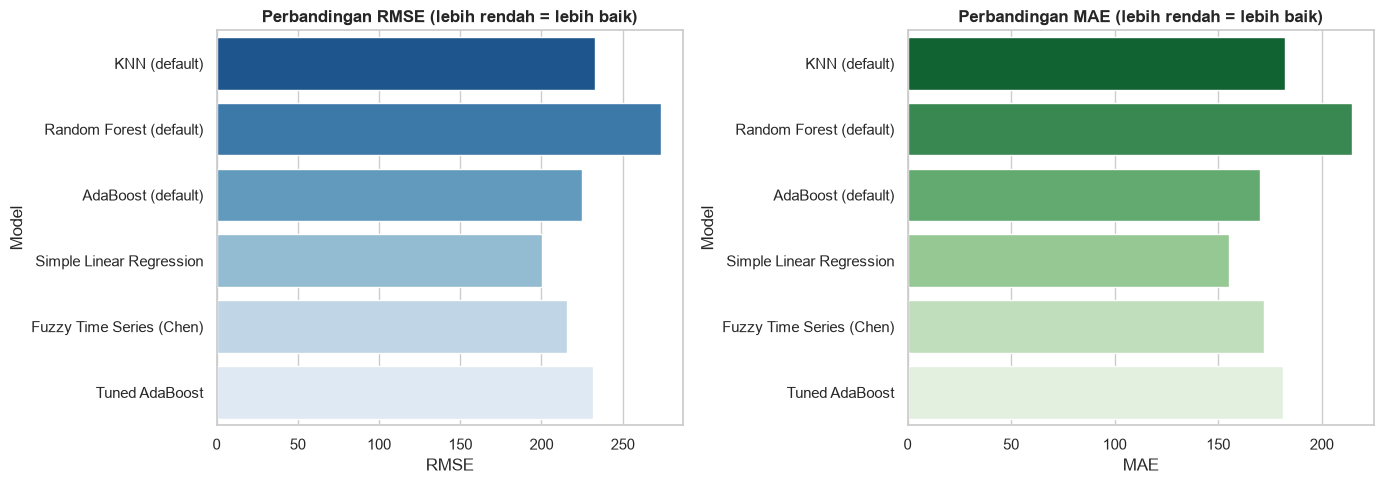


=== Model Terbaik ===
Model dengan RMSE terendah: Simple Linear Regression
RMSE: 200.2400
MAE : 155.4200


In [22]:
df_results = pd.DataFrame(results).T
df_results.index.name = 'Model'
print("=== Tabel Perbandingan Model ===")
display(df_results)

# Visualisasi perbandingan RMSE dan MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ambil hanya baris yang memiliki nilai numerik untuk RMSE dan MAE
rmse_vals = df_results['RMSE'].astype(float)
mae_vals  = df_results['MAE'].astype(float)

sns.barplot(x=rmse_vals.values, y=rmse_vals.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Perbandingan RMSE (lebih rendah = lebih baik)', fontweight='bold')
axes[0].set_xlabel('RMSE')

sns.barplot(x=mae_vals.values, y=mae_vals.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Perbandingan MAE (lebih rendah = lebih baik)', fontweight='bold')
axes[1].set_xlabel('MAE')

plt.tight_layout()
plt.show()

# Pilih model terbaik berdasarkan RMSE terendah
best_model_name = rmse_vals.idxmin()
print(f"\n=== Model Terbaik ===")
print(f"Model dengan RMSE terendah: {best_model_name}")
print(f"RMSE: {rmse_vals.min():,.4f}")
print(f"MAE : {mae_vals[best_model_name]:,.4f}")


## 11. Error Analysis dan Visualisasi Prediksi

Memvisualisasikan prediksi model terbaik (Tuned AdaBoost) vs nilai aktual untuk memahami pola kesalahan (*error*).


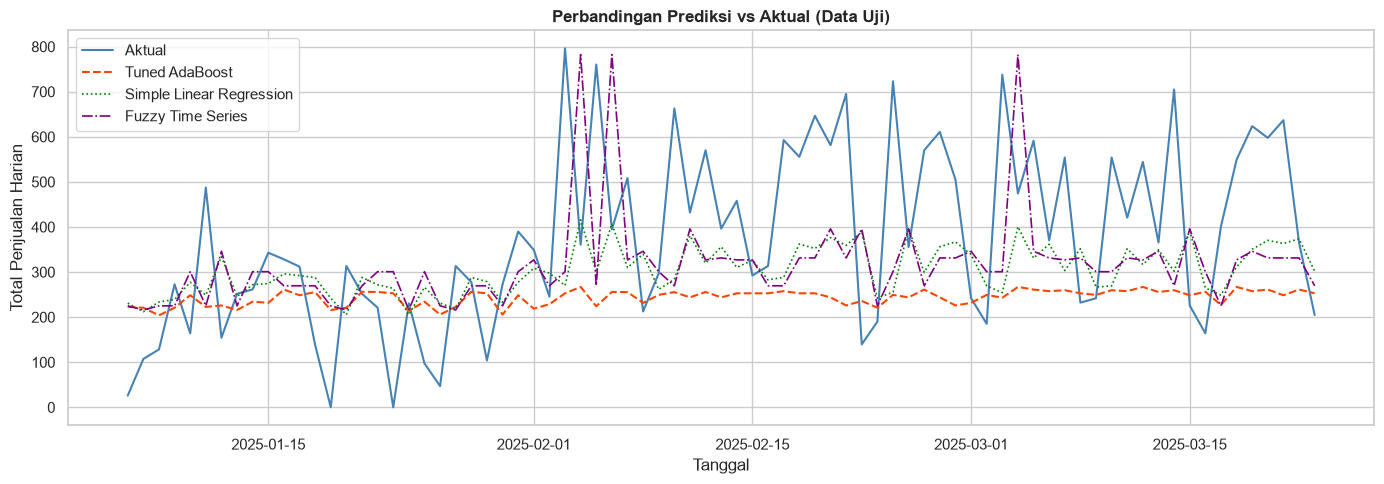

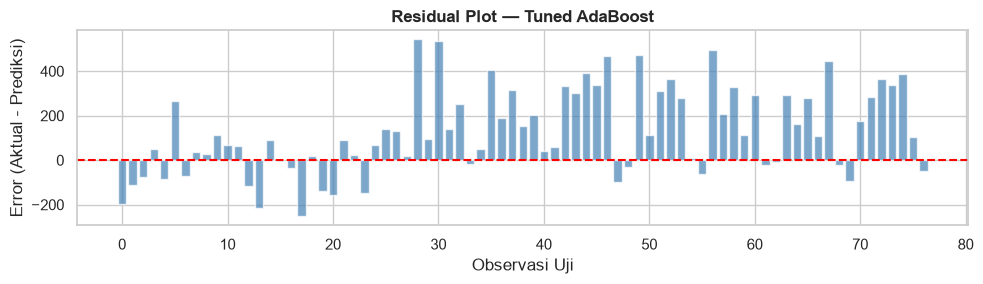

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, y_test.values,      label='Aktual',                   color='steelblue', linewidth=1.5)
ax.plot(test.index, best_ada_preds,     label='Tuned AdaBoost',           color='orangered',  linewidth=1.5, linestyle='--')
ax.plot(test.index, slr_preds,          label='Simple Linear Regression', color='green',      linewidth=1.2, linestyle=':')
ax.plot(test.index, fts_preds,          label='Fuzzy Time Series',        color='purple',     linewidth=1.2, linestyle='-.')
ax.set_title('Perbandingan Prediksi vs Aktual (Data Uji)', fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Total Penjualan Harian')
ax.legend()
plt.tight_layout()
plt.show()

# Residual plot
residuals = np.array(y_test) - best_ada_preds
plt.figure(figsize=(10, 3))
plt.axhline(0, color='red', linestyle='--')
plt.bar(range(len(residuals)), residuals, color='steelblue', alpha=0.7)
plt.title('Residual Plot — Tuned AdaBoost', fontweight='bold')
plt.xlabel('Observasi Uji')
plt.ylabel('Error (Aktual - Prediksi)')
plt.tight_layout()
plt.show()


## 12. Model Interpretation — Feature Importance

Mengidentifikasi fitur mana yang paling banyak berkontribusi pada prediksi model AdaBoost.

**Penting:** Feature importance hanya menunjukkan **tingkat asosiasi prediktif** yang digunakan oleh model — bukan bukti hubungan sebab-akibat (*kausalitas*). Fitur yang penting bagi model belum tentu menjadi penyebab tinggi/rendahnya penjualan.


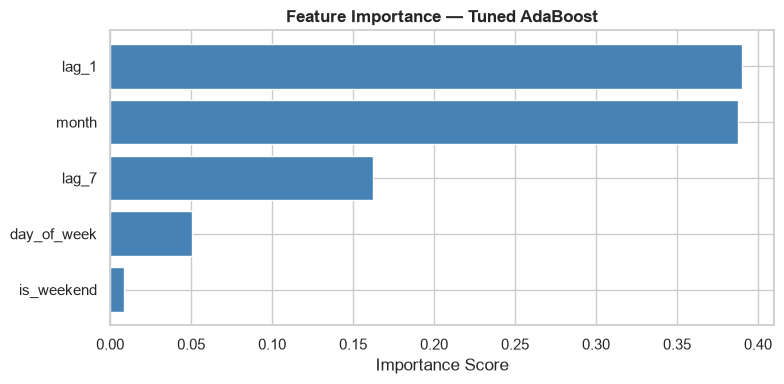

Interpretasi: Fitur dengan nilai importance tertinggi memiliki pengaruh prediktif terbesar dalam model.
Fitur ini TIDAK serta merta menjadi penyebab tinggi atau rendahnya penjualan.


In [24]:
importances = best_ada.feature_importances_
feat_imp_df = pd.DataFrame({
    'Fitur'    : features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp_df['Fitur'], feat_imp_df['Importance'], color='steelblue')
plt.title('Feature Importance — Tuned AdaBoost', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Interpretasi: Fitur dengan nilai importance tertinggi memiliki pengaruh prediktif terbesar dalam model.")
print("Fitur ini TIDAK serta merta menjadi penyebab tinggi atau rendahnya penjualan.")


## 13. Evaluation Summary dan Conclusion

### Metrik Evaluasi
- **MSE (Mean Squared Error):** Rata-rata kuadrat selisih antara nilai aktual dan prediksi. Formula: `MSE = (1/n) * Σ(y_i - ŷ_i)²`. Sensitif terhadap outlier; nilai lebih rendah lebih baik.
- **MAPE (Mean Absolute Percentage Error):** Rata-rata persentase error absolut. Formula: `MAPE = (1/n) * Σ|((y_i - ŷ_i)/y_i)| × 100%`. Interpretatif secara bisnis; tidak valid ketika nilai aktual = 0.
- **RMSE (Root Mean Squared Error):** Akar kuadrat MSE. Memiliki satuan yang sama dengan target; digunakan untuk perbandingan lintas model.
- **MAE (Mean Absolute Error):** Rata-rata error absolut. Formula: `MAE = (1/n) * Σ|y_i - ŷ_i|`. Lebih robust terhadap outlier dibandingkan MSE.

### Business Insights
1. Penjualan kopi dari vending machine memiliki pola harian dan mingguan yang dapat dimanfaatkan oleh model forecasting.
2. Pelanggan yang menggunakan kartu memiliki pola pembelian yang konsisten dan bisa diidentifikasi preferensi produknya.
3. Fitur `lag_1` (penjualan hari sebelumnya) merupakan prediktor paling penting, mengkonfirmasi bahwa penjualan harian bersifat auto-korelasi.

### Keterbatasan
- Dataset relatif singkat (< 1 tahun), sehingga model belum tentu menangkap musiman tahunan dengan baik.
- Hari dengan penjualan = 0 (vending machine tutup) dapat memengaruhi akurasi MAPE; oleh karena itu MAPE dihitung hanya pada hari dengan penjualan > 0.
- Model tidak memperhitungkan faktor eksternal seperti cuaca, event lokal, atau perubahan harga.

### Kesimpulan
Model terbaik dipilih berdasarkan nilai RMSE terendah pada data uji (bukan asumsi). Hasil lengkap dapat dilihat pada tabel perbandingan di Section 10. Pendekatan ini memenuhi dua Solution Statement yang diusulkan: (1) perbandingan lima algoritma, dan (2) hyperparameter tuning pada model terbaik.

---
*Referensi:*
1. Isaienkov, Y. (2025). Coffee Sales [Dataset]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/11159944
2. Sales Prediction using Linear Regression. ResearchGate. https://www.researchgate.net/publication/376738143_Sales_Prediction_using_Linear_Regression
3. [Penelitian FTS & SLR]. International Journal of Data and Operational Systems, 6(3). https://doi.org/10.56705/ijodas.v6i3.368
